In [1]:
# %%
import os
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import ParameterSampler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
# %%
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
TENSOR_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_tensors")
MODEL_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_models")
OUTPUT_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# %%
X_torch = torch.load(TENSOR_DIR / "X_features.pt")
y_torch = torch.load(TENSOR_DIR / "y_labels.pt")
fold_torch = torch.load(TENSOR_DIR / "folds.pt")

X_tf = tf.convert_to_tensor(X_torch.cpu().numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_torch.cpu().numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_torch.cpu().numpy(), dtype=tf.int64)

print("X shape:", X_tf.shape)
print("y shape:", y_tf.shape)
print("folds shape:", fold_tf.shape)

C:\Users\omarl\AppData\Local\Temp\ipykernel_26944\3665750501.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_torch = torch.load(TENSOR_DIR / "X_features.pt")
C:\Users\

X shape: (20931, 86, 65)
y shape: (20931,)
folds shape: (20931,)


In [5]:
# %%
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

target_names = ["SEG_A", "SEG_B", "SEG_C"]

print("X labeled:", X_labeled.shape)
print("y labeled:", y_labeled.shape)
print("fold labeled:", fold_labeled.shape)

print(pd.Series(y_labeled.numpy()).value_counts().sort_index())

X labeled: (11899, 86, 65)
y labeled: (11899,)
fold labeled: (11899,)
0    6406
1    3349
2    2144
Name: count, dtype: int64


In [6]:
# %%
test_fold = 3
val_fold = 4

train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train_tensor = tf.boolean_mask(X_labeled, train_mask)
y_train_tensor = tf.boolean_mask(y_labeled, train_mask)

X_val_tensor = tf.boolean_mask(X_labeled, val_mask)
y_val_tensor = tf.boolean_mask(y_labeled, val_mask)

X_test_tensor = tf.boolean_mask(X_labeled, test_mask)
y_test_tensor = tf.boolean_mask(y_labeled, test_mask)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Val:", X_val_tensor.shape, y_val_tensor.shape)
print("Test:", X_test_tensor.shape, y_test_tensor.shape)

Train: (7140, 86, 65) (7140,)
Val: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)


In [7]:
# %%
X_train_flat = X_train_tensor.numpy().reshape(X_train_tensor.shape[0], -1)
X_val_flat = X_val_tensor.numpy().reshape(X_val_tensor.shape[0], -1)
X_test_flat = X_test_tensor.numpy().reshape(X_test_tensor.shape[0], -1)

y_train_mc = y_train_tensor.numpy()
y_val_mc = y_val_tensor.numpy()
y_test_mc = y_test_tensor.numpy()

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)

print("y_train:", pd.Series(y_train_mc).value_counts().sort_index())
print("y_val:", pd.Series(y_val_mc).value_counts().sort_index())
print("y_test:", pd.Series(y_test_mc).value_counts().sort_index())

X_train_flat: (7140, 5590)
X_val_flat: (2379, 5590)
X_test_flat: (2380, 5590)
y_train: 0    3844
1    2009
2    1287
Name: count, dtype: int64
y_val: 0    1281
1     670
2     428
Name: count, dtype: int64
y_test: 0    1281
1     670
2     429
Name: count, dtype: int64


In [8]:
# %%
def evaluate_multiclass_predictions(y_true, y_pred, y_proba=None):
    report = classification_report(
        y_true,
        y_pred,
        target_names=["SEG_A", "SEG_B", "SEG_C"],
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "SEG_A_precision": report["SEG_A"]["precision"],
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_B_precision": report["SEG_B"]["precision"],
        "SEG_B_recall": report["SEG_B"]["recall"],
        "SEG_B_f1": report["SEG_B"]["f1-score"],
        "SEG_C_precision": report["SEG_C"]["precision"],
        "SEG_C_recall": report["SEG_C"]["recall"],
        "SEG_C_f1": report["SEG_C"]["f1-score"],
    }

    metrics["bc_recall_avg"] = (
        metrics["SEG_B_recall"] + metrics["SEG_C_recall"]
    ) / 2

    metrics["custom_score"] = (
        0.50 * metrics["macro_f1"] +
        0.30 * metrics["bc_recall_avg"] +
        0.20 * metrics["weighted_f1"]
    )

    return metrics

In [9]:
# %%
xgb_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [1, 2, 5, 10],
}

n_iter = 100

xgb_param_candidates = list(ParameterSampler(
    xgb_param_grid,
    n_iter=n_iter,
    random_state=SEED
))

len(xgb_param_candidates)

100

In [10]:
# %%
xgb_results = []
sample_weights_mc = compute_sample_weight(
    class_weight="balanced",
    y=y_train_mc
)

for i, params in enumerate(xgb_param_candidates, start=1):
    print("\n" + "=" * 80)
    print(f"Training XGB candidate {i}/{len(xgb_param_candidates)}")
    print(params)
    print("=" * 80)

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train_flat,
        y_train_mc,
        sample_weight=sample_weights_mc
    )

    val_proba = model.predict_proba(X_val_flat)
    val_pred = np.argmax(val_proba, axis=1)

    val_metrics = evaluate_multiclass_predictions(
        y_true=y_val_mc,
        y_pred=val_pred,
        y_proba=val_proba
    )

    result = {
        "candidate": i,
        **params,
        **val_metrics
    }

    xgb_results.append(result)

    print(
        f"Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Weighted F1: {val_metrics['weighted_f1']:.4f} | "
        f"SEG_B recall: {val_metrics['SEG_B_recall']:.4f} | "
        f"SEG_C recall: {val_metrics['SEG_C_recall']:.4f} | "
        f"Custom score: {val_metrics['custom_score']:.4f}"
    )

xgb_results_df = pd.DataFrame(xgb_results)

xgb_results_df.sort_values(
    ["custom_score", "macro_f1", "weighted_f1"],
    ascending=False
).head(15)


Training XGB candidate 1/100
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.05, 'colsample_bytree': 0.75}
Macro F1: 0.5503 | Weighted F1: 0.6376 | SEG_B recall: 0.5701 | SEG_C recall: 0.2383 | Custom score: 0.5239

Training XGB candidate 2/100
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.75}
Macro F1: 0.5711 | Weighted F1: 0.6454 | SEG_B recall: 0.5791 | SEG_C recall: 0.3528 | Custom score: 0.5544

Training XGB candidate 3/100
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.75}
Macro F1: 0.5769 | Weighted F1: 0.6496 | SEG_B recall: 0.5627 | SEG_C recall: 0.3925 | Custom score: 0.5616

Training XGB candidate 4/100
{'subsample': 0.9, 'reg

,candidate,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,...,SEG_A_recall,SEG_A_f1,SEG_B_precision,SEG_B_recall,SEG_B_f1,SEG_C_precision,SEG_C_recall,SEG_C_f1,bc_recall_avg,custom_score
37,38,1.0,10,0.50,200,7,5,0.05,0.05,0.60,...,0.786105,0.783963,0.581081,0.577612,0.579341,0.397647,0.394860,0.396249,0.486236,0.570446
32,33,0.8,10,0.50,500,1,3,0.03,0.20,0.60,...,0.774395,0.778956,0.592063,0.556716,0.573846,0.376812,0.425234,0.399561,0.490975,0.569940
57,58,0.9,1,0.10,200,1,3,0.03,0.05,0.75,...,0.772053,0.778127,0.588723,0.529851,0.557738,0.378641,0.455607,0.413574,0.492729,0.569486
43,44,0.7,5,0.01,300,5,3,0.03,0.05,1.00,...,0.772053,0.777516,0.592652,0.553731,0.572531,0.371429,0.425234,0.396514,0.489482,0.568186
25,26,1.0,5,0.00,700,3,3,0.01,0.05,0.85,...,0.769711,0.777296,0.587276,0.537313,0.561185,0.370588,0.441589,0.402985,0.489451,0.566898
78,79,1.0,10,0.00,700,5,5,0.01,0.05,0.60,...,0.774395,0.778650,0.575301,0.570149,0.572714,0.383929,0.401869,0.392694,0.486009,0.566722
49,50,0.7,2,0.50,200,5,5,0.03,0.20,0.60,...,0.781421,0.782643,0.570783,0.565672,0.568216,0.390411,0.399533,0.394919,0.482602,0.566243
19,20,0.8,2,0.10,200,7,5,0.03,0.00,1.00,...,0.779859,0.779251,0.577844,0.576119,0.576981,0.387850,0.387850,0.387850,0.481985,0.565650
45,46,0.8,10,0.00,200,1,5,0.07,0.20,0.85,...,0.800937,0.789838,0.581602,0.585075,0.583333,0.396907,0.359813,0.377451,0.472444,0.565001
46,47,0.8,1,0.50,700,1,3,0.01,0.10,0.85,...,0.772053,0.778434,0.580128,0.540299,0.559505,0.369697,0.427570,0.396533,0.483934,0.563873


In [11]:
# %%
xgb_results_path = MODEL_DIR / "xgb_multiclass_hyperparameter_search_results.csv"

xgb_results_df.to_csv(xgb_results_path, index=False)

print("Saved:", xgb_results_path)

Saved: C:\Users\omarl\Downloads\pfizer_models\xgb_multiclass_hyperparameter_search_results.csv


In [12]:
# %%
best_xgb_row = xgb_results_df.sort_values(
    ["macro_f1", "weighted_f1", "custom_score"],
    ascending=False
).iloc[0]

best_xgb_row

candidate            38.000000
subsample             1.000000
reg_lambda           10.000000
reg_alpha             0.500000
n_estimators        200.000000
min_child_weight      7.000000
max_depth             5.000000
learning_rate         0.050000
gamma                 0.050000
colsample_bytree      0.600000
accuracy              0.656999
macro_f1              0.586517
weighted_f1           0.656582
SEG_A_precision       0.781832
SEG_A_recall          0.786105
SEG_A_f1              0.783963
SEG_B_precision       0.581081
SEG_B_recall          0.577612
SEG_B_f1              0.579341
SEG_C_precision       0.397647
SEG_C_recall          0.394860
SEG_C_f1              0.396249
bc_recall_avg         0.486236
custom_score          0.570446
Name: 37, dtype: float64

In [13]:
# %%
xgb_param_cols = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "min_child_weight",
    "gamma",
    "reg_alpha",
    "reg_lambda"
]

best_xgb_params = {
    col: best_xgb_row[col]
    for col in xgb_param_cols
}

int_cols = ["n_estimators", "max_depth", "min_child_weight"]

for col in int_cols:
    best_xgb_params[col] = int(best_xgb_params[col])

for col in best_xgb_params:
    if col not in int_cols:
        best_xgb_params[col] = float(best_xgb_params[col])

best_xgb_params

{'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.05,
 'subsample': 1.0,
 'colsample_bytree': 0.6,
 'min_child_weight': 7,
 'gamma': 0.05,
 'reg_alpha': 0.5,
 'reg_lambda': 10.0}

In [14]:
# %%
X_trainval_flat = np.vstack([X_train_flat, X_val_flat])
y_trainval_mc = np.concatenate([y_train_mc, y_val_mc])

sample_weights_trainval_mc = compute_sample_weight(
    class_weight="balanced",
    y=y_trainval_mc
)

best_xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    **best_xgb_params
)

best_xgb_model.fit(
    X_trainval_flat,
    y_trainval_mc,
    sample_weight=sample_weights_trainval_mc
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.05, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=7, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=3, num_parallel_tree=None, ...)

In [15]:
# %%
test_xgb_proba = best_xgb_model.predict_proba(X_test_flat)
test_xgb_pred = np.argmax(test_xgb_proba, axis=1)

test_xgb_metrics = evaluate_multiclass_predictions(
    y_true=y_test_mc,
    y_pred=test_xgb_pred,
    y_proba=test_xgb_proba
)

test_xgb_metrics

{'accuracy': 0.6579831932773109,
 'macro_f1': 0.5865596230804149,
 'weighted_f1': 0.6580760570701445,
 'SEG_A_precision': 0.7942811755361397,
 'SEG_A_recall': 0.78064012490242,
 'SEG_A_f1': 0.7874015748031497,
 'SEG_B_precision': 0.5652173913043478,
 'SEG_B_recall': 0.6014925373134329,
 'SEG_B_f1': 0.5827910339840926,
 'SEG_C_precision': 0.39950980392156865,
 'SEG_C_recall': 0.37995337995337997,
 'SEG_C_f1': 0.38948626045400236,
 'bc_recall_avg': 0.4907229586334064,
 'custom_score': 0.5721119105442583}

In [16]:
# %%
print(classification_report(
    y_test_mc,
    test_xgb_pred,
    target_names=["SEG_A", "SEG_B", "SEG_C"]
))

              precision    recall  f1-score   support

       SEG_A       0.79      0.78      0.79      1281
       SEG_B       0.57      0.60      0.58       670
       SEG_C       0.40      0.38      0.39       429

    accuracy                           0.66      2380
   macro avg       0.59      0.59      0.59      2380
weighted avg       0.66      0.66      0.66      2380



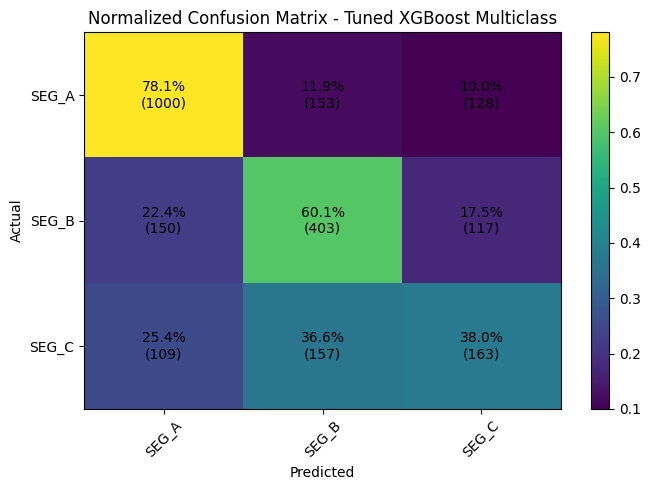

In [17]:
# %%
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    target_names,
    normalize=True,
    title="Confusion Matrix"
):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_display = cm / cm.sum(axis=1, keepdims=True)
    else:
        cm_display = cm
    
    plt.figure(figsize=(7, 5))
    plt.imshow(cm_display, aspect="auto")
    plt.colorbar()
    
    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_display[i, j]*100:.1f}%\n({cm[i, j]})"
            else:
                text = f"{cm[i, j]}"
            
            plt.text(j, i, text, ha="center", va="center")
    
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_with_percentages(
    y_true=y_test_mc,
    y_pred=test_xgb_pred,
    target_names=["SEG_A", "SEG_B", "SEG_C"],
    normalize=True,
    title="Normalized Confusion Matrix - Tuned XGBoost Multiclass"
)

In [18]:
# %%
xgb_model_path = MODEL_DIR / "best_xgb_multiclass_atseg_tuned.joblib"
xgb_metadata_path = MODEL_DIR / "xgb_multiclass_metadata.json"

joblib.dump(best_xgb_model, xgb_model_path)

metadata_xgb = {
    "model": "XGBClassifier",
    "task": "SEG_A vs SEG_B vs SEG_C",
    "best_params": best_xgb_params,
    "label_mapping": {
        "0": "SEG_A",
        "1": "SEG_B",
        "2": "SEG_C"
    },
    "test_metrics": test_xgb_metrics
}

with open(xgb_metadata_path, "w") as f:
    json.dump(metadata_xgb, f, indent=4)

print("Saved model:", xgb_model_path)
print("Saved metadata:", xgb_metadata_path)

Saved model: C:\Users\omarl\Downloads\pfizer_models\best_xgb_multiclass_atseg_tuned.joblib
Saved metadata: C:\Users\omarl\Downloads\pfizer_models\xgb_multiclass_metadata.json


In [19]:
# %%
test_predictions_xgb_df = pd.DataFrame({
    "true_label_encoded": y_test_mc,
    "true_label": [target_names[i] for i in y_test_mc],
    "pred_label_encoded": test_xgb_pred,
    "pred_label": [target_names[i] for i in test_xgb_pred],
    "prob_SEG_A": test_xgb_proba[:, 0],
    "prob_SEG_B": test_xgb_proba[:, 1],
    "prob_SEG_C": test_xgb_proba[:, 2],
})

xgb_test_predictions_path = OUTPUT_DIR / "xgb_multiclass_test_predictions.csv"

test_predictions_xgb_df.to_csv(xgb_test_predictions_path, index=False)

print("Saved:", xgb_test_predictions_path)

Saved: C:\Users\omarl\Downloads\pfizer_outputs\xgb_multiclass_test_predictions.csv
